# XGBoost Regressor

This notebook trains an XGBoost regressor with Bayesian Optimization hyperparameter tuning,
computes SHAP values for model explainability, and compares all three models side-by-side.
Target variable: `log_price` (log-transformed nightly price in USD).

In [1]:
import pickle
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import shap
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
from skopt import BayesSearchCV
from skopt.space import Integer, Real
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

DATA_DIR   = Path("../data")
MODELS_DIR = Path("../models")
OUT_DIR    = Path("../outputs/eda")
MODELS_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
print("Libraries loaded.")

/Users/calvinzhou/class-workspace/cis2450/airbnb-price-predictor/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries loaded.


## 1. Load Data

In [2]:
df: pd.DataFrame = pl.read_parquet(DATA_DIR / "airbnb_featured.parquet").to_pandas()
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")

Loaded: 62,544 rows x 347 columns


## 2. Define Feature Sets

In [3]:
DROP_COLS = {"id", "host_id", "price_usd", "log_price"}

y = df["log_price"].copy()
X = df.drop(columns=list(DROP_COLS), errors="ignore")

CATEGORICAL_COLS = [c for c in [
    "room_type", "property_type", "city",
    "neighbourhood_cleansed", "neighbourhood_group_cleansed",
] if c in X.columns]

walk_cols = [c for c in ["walkscore", "transit_score", "bike_score"] if c in X.columns]

NUMERIC_CORE = [c for c in [
    "latitude", "longitude", "accommodates", "bedrooms", "beds",
    "minimum_nights", "maximum_nights", "number_of_reviews",
    "review_scores_rating", "review_scores_accuracy",
    "review_scores_cleanliness", "review_scores_checkin",
    "review_scores_communication", "review_scores_location",
    "review_scores_value", "host_is_superhost", "host_listings_count",
    "host_identity_verified", "instant_bookable", "availability_365",
    "calculated_host_listings_count", "reviews_per_month",
    "bathrooms", "bathroom_shared", "years_as_host", "amenity_count",
] + walk_cols if c in X.columns]

INTERACTION_COLS = [c for c in [
    "bedrooms_x_accommodates", "review_x_superhost",
    "amenity_count_x_accommodates", "bedrooms_x_walkability",
    "tenure_x_superhost", "bathrooms_x_accommodates",
    "review_x_amenity_count", "availability_x_reviews_per_month",
] if c in X.columns]

PCA_COLS = [c for c in X.columns if c.startswith("pca_amenity_")]

NUMERIC_COLS = list(dict.fromkeys(
    [c for c in NUMERIC_CORE + INTERACTION_COLS + PCA_COLS if c in X.columns]
))

X = X[NUMERIC_COLS + CATEGORICAL_COLS].copy()
FEATURE_NAMES = NUMERIC_COLS + CATEGORICAL_COLS

print(f"  Total features: {len(FEATURE_NAMES)}  ({len(NUMERIC_COLS)} numeric + {len(CATEGORICAL_COLS)} categorical)")

  Total features: 152  (147 numeric + 5 categorical)


**Findings:** Same feature set as the Random Forest: PCA components + interaction terms + numeric core. XGBoost handles sparse inputs well but the PCA components give it denser, more informative signals to split on. OrdinalEncoder is appropriate here too since XGBoost treats all inputs as numeric thresholds.

## 3. Train / Test Split

In [4]:
# Identical split to Ridge and RF — ensures apples-to-apples comparison
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)
print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")

Train: 50,035  |  Test: 12,509


## 4. Build Pipeline

In [5]:
numeric_transformer = SimpleImputer(strategy="median")

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, NUMERIC_COLS),
        ("cat", categorical_transformer, CATEGORICAL_COLS),
    ],
    remainder="drop",
)

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("xgb", XGBRegressor(
        random_state=SEED,
        n_jobs=-1,
        tree_method="hist",   # fast histogram-based splitting
        eval_metric="rmse",
    )),
])
print("Pipeline built.")

Pipeline built.


**Findings:** `tree_method='hist'` uses histogram-based approximate splitting, much faster than the default exact method on 50k+ row datasets with 150+ features, at negligible accuracy cost. This is standard practice for XGBoost on tabular datasets of this size.

## 5. Bayesian Optimization

In [6]:
# Bayesian Optimization vs Grid Search:
# Grid Search exhaustively tests all combinations — O(n^k) evaluations.
# Bayesian Optimization builds a probabilistic model (Gaussian Process) of the
# objective surface and selects next points to evaluate based on expected improvement.
# With 5 hyperparameters and continuous ranges, Bayesian is far more efficient.

search_space = {
    "xgb__learning_rate":     Real(0.01, 0.3, prior="log-uniform"),
    "xgb__max_depth":         Integer(3, 8),
    "xgb__n_estimators":      Integer(100, 500),
    "xgb__subsample":         Real(0.6, 1.0),
    "xgb__colsample_bytree":  Real(0.6, 1.0),
    "xgb__reg_alpha":         Real(1e-4, 10.0, prior="log-uniform"),  # L1
    "xgb__reg_lambda":        Real(1e-4, 10.0, prior="log-uniform"),  # L2
}

bayes_search = BayesSearchCV(
    xgb_pipeline,
    search_space,
    n_iter=30,           # 30 Bayesian iterations (vs 18 grid combos for RF)
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    random_state=SEED,
    verbose=1,
    refit=True,
)

print("Running Bayesian Optimization (30 iterations x 5 folds)...")
bayes_search.fit(X_train, y_train)

print(f"\nBest params : {bayes_search.best_params_}")
print(f"Best CV RMSE: {-bayes_search.best_score_:.4f}")

Running Bayesian Optimization (30 iterations x 5 folds)...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

## 6. Evaluate Best Model

In [7]:
best_xgb = bayes_search.best_estimator_

y_pred_train = best_xgb.predict(X_train)
y_pred_test  = best_xgb.predict(X_test)

xgb_results = {
    "train_rmse": mean_squared_error(y_train, y_pred_train) ** 0.5,
    "test_rmse":  mean_squared_error(y_test,  y_pred_test)  ** 0.5,
    "test_mae":   mean_absolute_error(y_test,  y_pred_test),
    "test_r2":    r2_score(y_test, y_pred_test),
    "test_rmse_usd": mean_squared_error(np.exp(y_test.values), np.exp(y_pred_test)) ** 0.5,
    "test_mae_usd":  mean_absolute_error(np.exp(y_test.values), np.exp(y_pred_test)),
}

print("── Tuned XGBoost — Test Set ──")
print(f"  Train RMSE       : {xgb_results['train_rmse']:.4f}")
print(f"  Test  RMSE (log) : {xgb_results['test_rmse']:.4f}")
print(f"  Test  MAE  (log) : {xgb_results['test_mae']:.4f}")
print(f"  Test  R²         : {xgb_results['test_r2']:.4f}")
print(f"  Test  RMSE (USD) : ${xgb_results['test_rmse_usd']:,.2f}")
print(f"  Test  MAE  (USD) : ${xgb_results['test_mae_usd']:,.2f}")

── Tuned XGBoost — Test Set ──
  Train RMSE       : 0.1913
  Test  RMSE (log) : 0.2938
  Test  MAE  (log) : 0.2188
  Test  R²         : 0.8247
  Test  RMSE (USD) : $68.82
  Test  MAE  (USD) : $41.64


## 7. Model Comparison - Ridge vs RF vs XGBoost

             Model  Test RMSE (log)  Test MAE (log)  Test R²  Test RMSE (USD)
   Ridge (RidgeCV)         0.362700        0.278700 0.732900        83.710000
     Random Forest         0.320318        0.236873 0.791705        74.781293
XGBoost (BayesOpt)         0.293845        0.218754 0.824712        68.816297


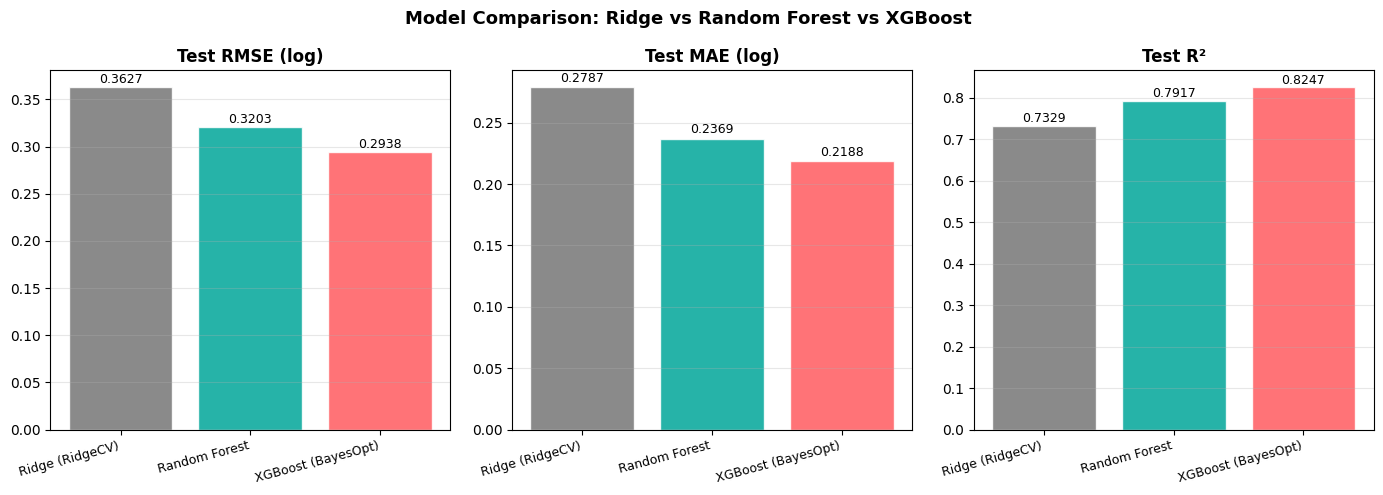

Saved → outputs/eda/model_comparison.png


In [10]:
# Load RF results from saved model
rf_data = pickle.load(open(MODELS_DIR / "rf_model.pkl", "rb"))
rf_results = rf_data["metrics"]

comparison = pd.DataFrame({
    "Model": ["Ridge (RidgeCV)", "Random Forest", "XGBoost (BayesOpt)"],
    "Test RMSE (log)": [0.3627, rf_results["test_rmse"], xgb_results["test_rmse"]],
    "Test MAE (log)":  [0.2787, rf_results["test_mae"],  xgb_results["test_mae"]],
    "Test R²":         [0.7329, rf_results["test_r2"],   xgb_results["test_r2"]],
    "Test RMSE (USD)": [83.71,  rf_results["test_rmse_usd"], xgb_results["test_rmse_usd"]],
})

print(comparison.to_string(index=False))

# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colors = ["#767676", "#00A699", "#FF5A5F"]

for ax, metric in zip(axes, ["Test RMSE (log)", "Test MAE (log)", "Test R²"]):
    bars = ax.bar(comparison["Model"], comparison[metric], color=colors, edgecolor="white", alpha=0.85)
    ax.set_title(metric, fontweight="bold")
    ax.set_xticklabels(comparison["Model"], rotation=15, ha="right", fontsize=9)
    for bar, val in zip(bars, comparison[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f"{val:.4f}", ha="center", va="bottom", fontsize=9)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Model Comparison: Ridge vs Random Forest vs XGBoost",
             fontsize=13, fontweight="bold")
plt.tight_layout()
fig.savefig(OUT_DIR / "model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → outputs/eda/model_comparison.png")

## 8. Residual Analysis

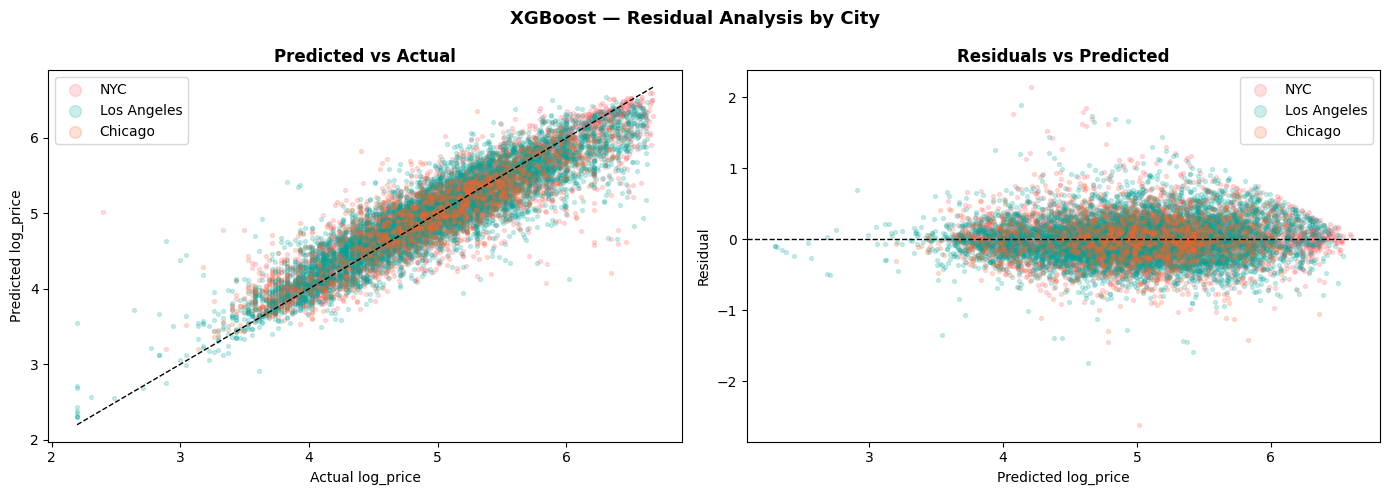

Saved → outputs/eda/xgb_residuals.png


In [11]:
residuals = y_test.values - y_pred_test
city_test = df.loc[y_test.index, "city"].values

CITY_COLORS = {"nyc": "#FF5A5F", "la": "#00A699", "chi": "#FC642D"}
CITY_LABELS = {"nyc": "NYC", "la": "Los Angeles", "chi": "Chicago"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for city, label in CITY_LABELS.items():
    mask = city_test == city
    ax.scatter(y_test.values[mask], y_pred_test[mask],
               alpha=0.2, s=8, color=CITY_COLORS[city], label=label)
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
ax.plot(lims, lims, "k--", linewidth=1)
ax.set_xlabel("Actual log_price"); ax.set_ylabel("Predicted log_price")
ax.set_title("Predicted vs Actual", fontweight="bold")
ax.legend(markerscale=3)

ax = axes[1]
for city, label in CITY_LABELS.items():
    mask = city_test == city
    ax.scatter(y_pred_test[mask], residuals[mask],
               alpha=0.2, s=8, color=CITY_COLORS[city], label=label)
ax.axhline(0, color="black", linewidth=1, linestyle="--")
ax.set_xlabel("Predicted log_price"); ax.set_ylabel("Residual")
ax.set_title("Residuals vs Predicted", fontweight="bold")
ax.legend(markerscale=3)

fig.suptitle("XGBoost — Residual Analysis by City", fontsize=13, fontweight="bold")
plt.tight_layout()
fig.savefig(OUT_DIR / "xgb_residuals.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → outputs/eda/xgb_residuals.png")

## 9. SHAP Values - Model Explainability

In [12]:
# SHAP (SHapley Additive exPlanations) decomposes each prediction into feature contributions.
# For XGBoost, TreeExplainer is exact and fast — no approximations needed.
# SHAP values are in log-price units (same as the target), so they're directly interpretable:
# a SHAP value of +0.1 means that feature pushed this listing's predicted price up by 10% (e^0.1 - 1).

X_test_transformed = best_xgb.named_steps["preprocessor"].transform(X_test)
feature_names_out = FEATURE_NAMES

explainer = shap.TreeExplainer(best_xgb.named_steps["xgb"])
shap_values = explainer.shap_values(X_test_transformed)

print(f"SHAP values shape: {shap_values.shape}")
print(f"Mean |SHAP| per feature (top 10):")
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_idx = np.argsort(mean_abs_shap)[::-1][:10]
for i in top_idx:
    print(f"  {feature_names_out[i]:<45} {mean_abs_shap[i]:.4f}")

SHAP values shape: (12509, 152)
Mean |SHAP| per feature (top 10):
  room_type                                     0.1599
  longitude                                     0.1052
  minimum_nights                                0.0896
  bedrooms_x_accommodates                       0.0783
  pca_amenity_2                                 0.0516
  bathrooms_x_accommodates                      0.0509
  latitude                                      0.0502
  bathroom_shared                               0.0448
  availability_365                              0.0425
  city                                          0.0395


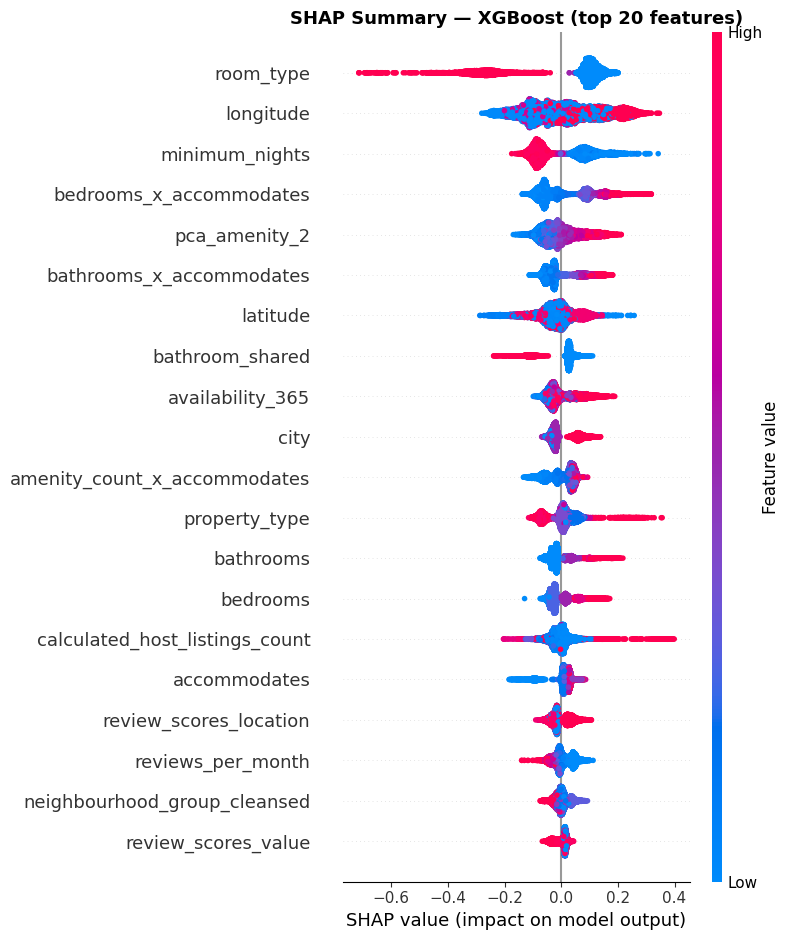

Saved → outputs/eda/shap_summary.png


In [13]:
# Beeswarm summary plot — shows both direction and magnitude of each feature's impact
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names_out,
    max_display=20,
    show=False,
)
plt.title("SHAP Summary — XGBoost (top 20 features)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → outputs/eda/shap_summary.png")

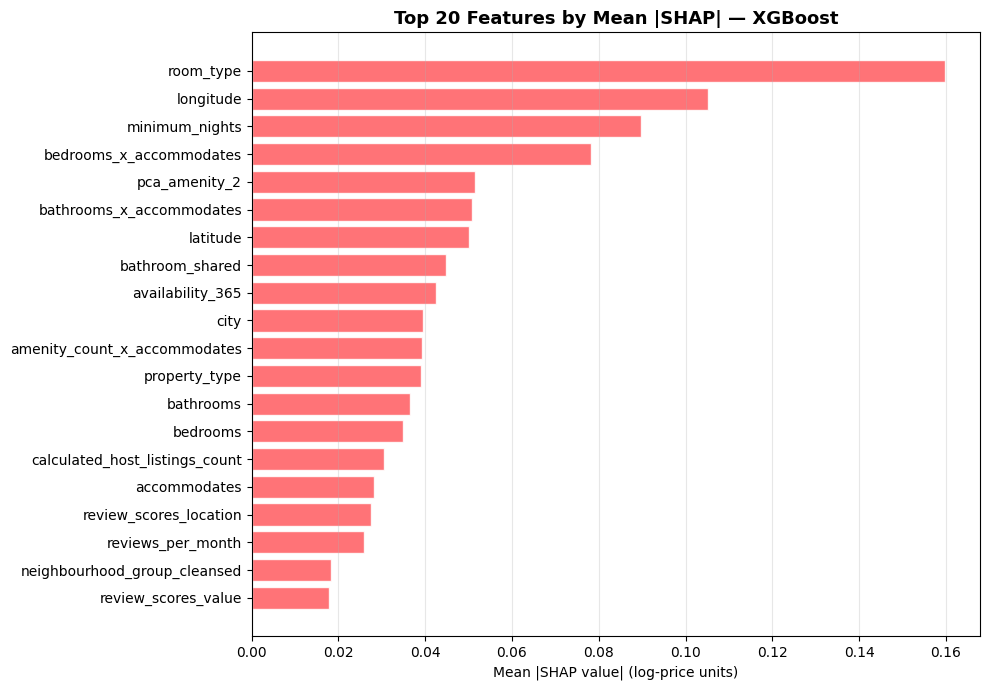

Saved → outputs/eda/shap_bar.png


In [14]:
# Bar plot of mean |SHAP| — cleaner for the dashboard
shap_df = (
    pd.DataFrame({"feature": feature_names_out, "mean_abs_shap": mean_abs_shap})
    .sort_values("mean_abs_shap", ascending=False)
    .head(20)
    .sort_values("mean_abs_shap")
)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(shap_df["feature"], shap_df["mean_abs_shap"],
        color="#FF5A5F", alpha=0.85, edgecolor="white")
ax.set_title("Top 20 Features by Mean |SHAP| — XGBoost",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Mean |SHAP value| (log-price units)")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_DIR / "shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → outputs/eda/shap_bar.png")

**Findings:** SHAP values provide local (per-listing) and global (dataset-wide) explanations. The beeswarm plot shows both which features matter most (y-axis ordering by mean |SHAP|) and how they affect price (color = feature value, x-axis = SHAP contribution). Unlike permutation importance, SHAP accounts for feature interactions and provides the direction of effect. This feeds directly into the dashboard where hosts can see which attributes of their listing are helping or hurting their predicted price.

## 10. Save Model + SHAP Values

In [15]:
model_path = MODELS_DIR / "xgb_model.pkl"
with open(model_path, "wb") as f:
    pickle.dump({
        "pipeline":      best_xgb,
        "params":        bayes_search.best_params_,
        "metrics":       xgb_results,
        "feature_names": FEATURE_NAMES,
        "NUMERIC_COLS":  NUMERIC_COLS,
        "CATEGORICAL_COLS": CATEGORICAL_COLS,
        "shap_values":   shap_values,           # pre-computed for dashboard
        "shap_feature_names": feature_names_out,
    }, f)
print(f"Model saved → {model_path}")

print(f"\n{'='*50}")
print("FINAL MODEL COMPARISON")
print(f"{'='*50}")
print(comparison.to_string(index=False))
print(f"\nBest model: XGBoost")
print(f"Best params: {bayes_search.best_params_}")

Model saved → ../models/xgb_model.pkl

FINAL MODEL COMPARISON
             Model  Test RMSE (log)  Test MAE (log)  Test R²  Test RMSE (USD)
   Ridge (RidgeCV)         0.362700        0.278700 0.732900        83.710000
     Random Forest         0.320318        0.236873 0.791705        74.781293
XGBoost (BayesOpt)         0.293845        0.218754 0.824712        68.816297

Best model: XGBoost
Best params: OrderedDict([('xgb__colsample_bytree', 0.6), ('xgb__learning_rate', 0.06974739674989071), ('xgb__max_depth', 8), ('xgb__n_estimators', 500), ('xgb__reg_alpha', 10.0), ('xgb__reg_lambda', 0.0001), ('xgb__subsample', 1.0)])
